# Neural Network

In [56]:
import math
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from utils import *
from logistic_regression import LogisticRegression

## Load Data

In [49]:
def load_data_npy():
    X = np.load("data/X.npy")
    y = np.load("data/y.npy")
    X = X[0:1000]
    y = y[0:1000]
    return X, y

def sigmoid(x):
    return 1. / (1. + np.exp(-x))

X, y = load_data_npy()

print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))
# print ('The first element of X is: ', X[0])

The first element of y is:  0
The last element of y is:  1
The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


## Visualizate the data

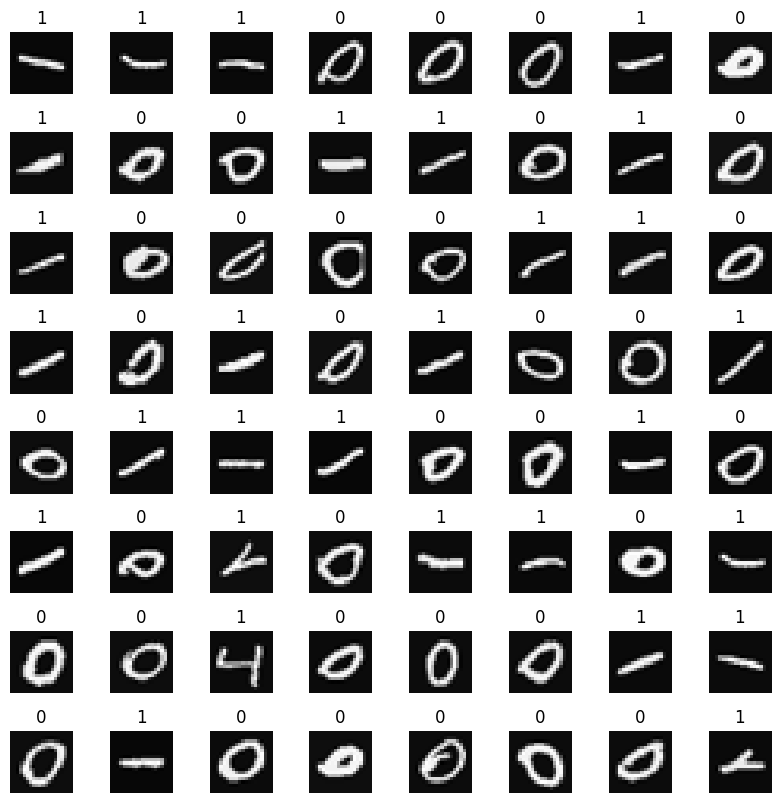

In [50]:
m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20))
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

In [118]:
from abc import abstractmethod
from typing import Tuple

class ActivationFunction:
    def __init__(self):
        pass

    def compute_f(self, X, w, b) -> NDArray:
        z = np.dot(X, w) + b
        return self.activation(z)

    @abstractmethod
    def activation(self, z: NDArray) -> NDArray:
        pass

    @abstractmethod
    def derivative(self, z: NDArray) -> NDArray:
        pass

class SigmoidActivation(ActivationFunction):

    def activation(self, z: NDArray) -> NDArray:
        g = 1 / (1 + np.exp(-z))
        return g

    def derivative(self, z: NDArray) -> NDArray:
        return z * (1 - z)

class NeuralLayer:
    def __init__(self, units: int, activation: ActivationFunction, lr: float = 0.01, lambda_: float = 0):
        self.units = units
        self.activation = activation
        self.lr = lr
        self.lambda_ = lambda_
    
    def set_weights(self, w: NDArray, b: NDArray):
        self.w = w
        self.b = b
    
    def init_weights(self, dim_in: int):
        self.w = 0.5 * (np.random.randn(dim_in, self.units) - 0.5)
        self.b = np.random.randn(self.units)
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        return self.w, self.b

    def forward(self, a_in: NDArray) -> NDArray:
        self.a_in = a_in
        m, n = a_in.shape
        if 'w' not in self.__dict__ or 'b' not in self.__dict__:
            self.init_weights(n)
        self.a_out = self.activation.compute_f(a_in, self.w, self.b)
        return self.a_out
    
    def backward(self, loss: NDArray):
        
        dj_dw, dj_db = self.compute_gradient(loss)
        print(f'shape: w {self.w.shape}, dj_dw {dj_dw.shape}, b {self.b.shape}, dj_db {dj_db.shape}， loss {loss.shape}')
        self.w -= self.lr * dj_dw
        self.b -= self.lr * dj_db

        err = np.dot(loss, self.w.T)
        err_bwd = err * self.activation.derivative(self.a_in)
        return err_bwd

    def compute_gradient(self, loss: NDArray):
        m = self.a_in.shape[0]
        err = np.dot(self.w, loss.T)
        dj_dw = (err + self.lambda_ * self.w) / m
        dj_db = err / m

        return dj_dw, dj_db


class NeuralNetwork:
    def __init__(self):
        self.layers: list[NeuralLayer] = []
    
    def add_layer(self, layer: NeuralLayer):
        self.layers.append(layer)
    
    def get_layers(self) -> list[NeuralLayer]:
        return self.layers

    def compute_cost(self, p_hat: NDArray, y: NDArray, lambda_: float = 0) -> Tuple[float, NDArray]:
        m = y.shape[0]
        loss = (-y * np.log(p_hat)) - (1 - y) * np.log(1 - p_hat)
        cost_without_reg = sum(loss.flatten()) / m

        reg_cost = 0
        w_num = 0
        for layer in self.layers:
            w, _ = layer.weights()
            reg_cost += sum(np.square(w.flatten()).flatten())
            w_num += w.shape[1]

        cost = cost_without_reg + (lambda_ / (2 * w_num)) * reg_cost
        return cost, loss

    def forward(self, X) -> NDArray:
        a = X
        for layer in self.layers:
            a = layer.forward(a)
        
        return a
    
    def backward(self, loss: NDArray):
        dz = loss
        for layer in reversed(self.layers):
            dz = layer.backward(dz)

    def fit(self, X: NDArray, y: NDArray, epochs: int, lambda_: float = 0) -> NDArray:
        num_prints = max(1, math.ceil(epochs / 10))
        for i in range(epochs):
            p_hat = self.forward(X)
            cost, loss = self.compute_cost(p_hat, y)
            if i % num_prints == 0:
                print(f'Epoch {i:10d}: Cost {cost:8.4f}')
            
            self.backward(loss)

        return p_hat

    def predict(self, X) -> NDArray:
        p_hat = self.forward(X)
        return p_hat


def test_neural_network():
    x_tst = 0.1*np.arange(1,3,1).reshape(1,2)  # (1 examples, 2 features)
    W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
    b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
    print(f'x_tst shape: {x_tst.shape}, W_tst shape: {W_tst.shape}, b_tst shape: {b_tst.shape}')
    nn_test = NeuralNetwork()
    layer = NeuralLayer(3, SigmoidActivation())
    layer.set_weights(W_tst, b_tst)
    nn_test.add_layer(layer)
    print(nn_test.predict(x_tst))
        
nn = NeuralNetwork()
nn.add_layer(NeuralLayer(25, SigmoidActivation()))
nn.add_layer(NeuralLayer(15, SigmoidActivation()))
nn.add_layer(NeuralLayer(1, SigmoidActivation()))
def train():
    p_hat = nn.fit(X, y, 10)
    print(f'X shape: {X.shape}')
    print(f'y shep: {y.shape}')
    print(f'p_hat shape: {p_hat.shape}')
    layers = nn.get_layers()
    for i in range(len(layers)):
        w, b = layers[i].weights()
        print(f'[Layer {i:2d}] w shape: {w.shape}, b shape: {b.shape}')

    plot_data(p_hat, y[:,0], pos_label="y=1", neg_label="y=0")

def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = X[:,0] > 0.5
    negative = X[:,0] <= 0.5
    
    # Plot examples
    plt.plot(X[negative, 0], y[negative], 'yo', label=neg_label)
    plt.plot(X[positive, 0], y[positive], 'b+', label=pos_label)


def test_predict():
    p_hat = nn.predict(X).flatten()
    p = np.zeros(p_hat.shape[0])
    postive_idx = p_hat > 0.5
    p[postive_idx] = 1
    print(f'Train Accuracy: {np.mean(p == y) * 100:3.2f}%')

    m, n = X.shape
    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)
    for i,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        X_random_reshaped = X[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(X_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(f'{int(p[random_index])}({p_hat[random_index]:.2f})/{y[random_index,0]}')
        ax.set_axis_off()

# test_neural_network()
train()
# test_predict()


Epoch          0: Cost -88.3349
shape: w (15, 1), dj_dw (15, 1000), b (1,), dj_db (15, 1000)， loss (1000, 1)


ValueError: non-broadcastable output operand with shape (15,1) doesn't match the broadcast shape (15,1000)